# Renger 2026 Figure 2(c-f) Qualitative Reproduction

**Audience**
- Julia users already comfortable with `QuantumCircuit.jl` who want a compact exact-circuit reproduction of the local physics behind Fig. 2(c)-(f) of the Renger 2026 paper.

**Prerequisites**
- Basic Julia syntax.
- Familiarity with `CompositeSystem`, `build_model`, `spectrum`, and `evolve`.
- A working local checkout of this repository.

**What You Will Learn**
- How to build two reduced exact-circuit local branches from the baseline Renger snapshot: `QB1-TC1-CR` for MOVE and `QB2-TC2-CR` for CZ.
- How to track dressed avoided crossings against locally defined diabatic states.
- How to generate paper-aligned fixed-window qubit excited-state maps for Fig. 2(e) and Fig. 2(f) on derived frequency axes.
- How to separate a resonance map from a fully calibrated logical gate.

**Runtime Profile**
- Reduced exact-circuit defaults: `charge_cutoff = 3`, `TC ncut = 4`, and compact exploratory flux windows for the spectroscopy and fixed-window map panels.
- Optional truncation checks are present but disabled by default.

**Important Caveat**
- The snapshot used here is the baseline local-prior model, with the central resonator fixed at `4.2 GHz`.
- The notebook is an exploratory reduced exact-circuit study of the local `QB-TC-CR` physics behind the paper panels.
- Appendix D measures the CZ calibration landscape through a higher-level pulse-and-readout sequence; here we use the local branch qubit excited-state probability as the clean reduced-model proxy.


## Outline

1. Activate the local environment and import the exact-circuit tools used in this notebook.
2. Load the frozen Renger priors and summarize the local `QB1`, `TC1`, and `CR` parameters.
3. Build notebook-local helpers for a reduced exact-circuit `QB-TC-CR` model.
4. Reproduce a MOVE-like avoided crossing between states approximating `|eg0⟩` and `|gg1⟩`.
5. Reproduce a CZ-like avoided crossing between states approximating `|eg1⟩` and `|fg0⟩`.
6. Generate a fixed-window MOVE population scan analogous to Fig. 2(e).
7. Generate a fixed-window CZ resonance scan analogous to Fig. 2(f).
8. Check one flux-quench sanity case with `FluxControl` and show why this notebook stops at resonance physics rather than claiming a finished logical gate calibration.


In [45]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl repository root from $(start).")
end

repo_root = find_repo_root(pwd())
Pkg.activate(repo_root)
Pkg.instantiate()

using Printf
using CairoMakie
using QuantumCircuit
using QuantumToolbox: basis, dag, eigenstates, kron, Ket, QuantumObject

include(joinpath(repo_root, "output", "jupyter-notebook", "makie_helpers.jl"))
activate_notebook_theme!()

const FIG2_CHARGE_CUTOFF = 3
const FIG2_MOVE_PLOT_TC_FLUX = 0.34
const FIG2_CZ_PLOT_TC_FLUX = 0.34
const FIG2_MOVE_T_GATE = 100.0
const FIG2_CZ_T_GATE = 120.0
const RUN_TRUNCATION_CHECKS = false
figure_exports = Dict{Symbol, NamedTuple}()

nothing


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


## Step 1 - Build a local exact-circuit model and local-eigenstate labels

The key modeling detail is that the exact-circuit basis used internally by `QuantumCircuit.jl` is a charge basis, not a dressed transmon basis. For Fig. 2(c)-(f), we therefore define the diabatic labels `|g⟩`, `|e⟩`, and `|f⟩` from the **isolated local exact-circuit eigenstates** of the qubit and coupler, then tensor those with resonator Fock states.

This keeps the avoided-crossing labels physically meaningful while the coupled `QB-TC-CR` model still uses the full circuit Hamiltonian.


In [46]:
snapshot = load_renger2026_snapshot()

round4(x::Real) = round(Float64(x); digits = 4)
compact_value(x) = x isa Real ? round4(x) : x
compact_namedtuple(nt::NamedTuple) = (; (key => compact_value(value) for (key, value) in pairs(nt))...)

const FIG2_COLORS = (
    diabatic_a = :gray40,
    diabatic_b = :gray65,
    dressed_a = :royalblue3,
    dressed_b = :firebrick3,
)

const FIG2_BRANCHES = (
    move = (label = "QB1-TC1-CR", qb_key = :QB1, tc_key = :TC1, beta_qc_key = "beta_qc_qb1"),
    cz = (label = "QB2-TC2-CR", qb_key = :QB2, tc_key = :TC2, beta_qc_key = "beta_qc_qb2"),
)

branch_spec(branch::Symbol) = getproperty(FIG2_BRANCHES, branch)

function parameter_rows(snapshot)
    return [
        (
            device = "QB1",
            fit = snapshot.devices[:QB1]["fit_classification"],
            f01_ghz = round4(snapshot.devices[:QB1]["f01_ghz"]),
            EC_ghz = round4(snapshot.devices[:QB1]["EC"]),
            EJmax_ghz = round4(snapshot.devices[:QB1]["EJmax"]),
            flux = round4(snapshot.devices[:QB1]["flux"]),
            asymmetry = round4(snapshot.devices[:QB1]["asymmetry"]),
        ),
        (
            device = "TC1",
            fit = snapshot.devices[:TC1]["fit_classification"],
            f01_ghz = round4(snapshot.devices[:TC1]["f01_ghz"]),
            EC_ghz = round4(snapshot.devices[:TC1]["EC"]),
            EJmax_ghz = round4(snapshot.devices[:TC1]["EJmax"]),
            flux = round4(snapshot.devices[:TC1]["flux"]),
            asymmetry = round4(snapshot.devices[:TC1]["asymmetry"]),
        ),
        (
            device = "QB2",
            fit = snapshot.devices[:QB2]["fit_classification"],
            f01_ghz = round4(snapshot.devices[:QB2]["f01_ghz"]),
            EC_ghz = round4(snapshot.devices[:QB2]["EC"]),
            EJmax_ghz = round4(snapshot.devices[:QB2]["EJmax"]),
            flux = round4(snapshot.devices[:QB2]["flux"]),
            asymmetry = round4(snapshot.devices[:QB2]["asymmetry"]),
        ),
        (
            device = "TC2",
            fit = snapshot.devices[:TC2]["fit_classification"],
            f01_ghz = round4(snapshot.devices[:TC2]["f01_ghz"]),
            EC_ghz = round4(snapshot.devices[:TC2]["EC"]),
            EJmax_ghz = round4(snapshot.devices[:TC2]["EJmax"]),
            flux = round4(snapshot.devices[:TC2]["flux"]),
            asymmetry = round4(snapshot.devices[:TC2]["asymmetry"]),
        ),
        (
            device = "CR",
            fit = "paper target",
            f01_ghz = round4(snapshot.targets["cr_f01_ghz"]),
            EC_ghz = missing,
            EJmax_ghz = missing,
            flux = missing,
            asymmetry = missing,
        ),
    ]
end

function subsystem_by_name(system::CompositeSystem, target::Symbol)
    for subsystem in subsystems(system)
        name(subsystem) == target && return subsystem
    end
    error("No subsystem named $(target) exists in the system.")
end

function local_qb(flux; branch = :move)
    spec = branch_spec(branch)
    p = snapshot.devices[spec.qb_key]
    return TunableTransmon(
        :QB;
        EJmax = p["EJmax"],
        EC = p["EC"],
        flux = flux,
        asymmetry = p["asymmetry"],
        ng = p["ng"],
        ncut = 5,
    )
end

function local_tc(flux; branch = :move)
    spec = branch_spec(branch)
    p = snapshot.devices[spec.tc_key]
    return TunableCoupler(
        :TC;
        EJmax = p["EJmax"],
        EC = p["EC"],
        flux = flux,
        asymmetry = p["asymmetry"],
        ng = p["ng"],
        ncut = 4,
    )
end

local_cr() = Resonator(:CR; ω = snapshot.targets["cr_f01_ghz"], dim = 3)
local_spec(; charge_cutoff = FIG2_CHARGE_CUTOFF) = CircuitHamiltonianSpec(charge_cutoff = charge_cutoff)

function local_exact_system(; branch = :move, q_flux = 0.20, tc_flux = 0.34)
    spec = branch_spec(branch)
    return CompositeSystem(
        local_qb(q_flux; branch),
        local_tc(tc_flux; branch),
        local_cr(),
        CircuitCapacitiveCoupling(:QB, :TC; G = snapshot.targets[spec.beta_qc_key]),
        CircuitCapacitiveCoupling(:TC, :CR; G = snapshot.targets["beta_cr"]),
    )
end

function retuned_system(base_system::CompositeSystem; q_flux, tc_flux)
    step1 = with_subsystem_parameter(base_system, :QB, :flux, q_flux)
    return with_subsystem_parameter(step1, :TC, :flux, tc_flux)
end

function local_eigenbundle(subsystem; charge_cutoff = FIG2_CHARGE_CUTOFF)
    model = build_model(CompositeSystem(subsystem); hamiltonian_spec = CircuitHamiltonianSpec(charge_cutoff = charge_cutoff))
    es = eigenstates(hamiltonian(model))
    values = Float64.(real.(es.values))
    dims = basis(model.dimensions[name(subsystem)], 0).dims
    states = [QuantumObject(es.vectors[:, i]; type = Ket(), dims = dims) for i in axes(es.vectors, 2)]
    return values, states
end

q_bundle(flux; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF) = local_eigenbundle(local_qb(flux; branch); charge_cutoff)
tc_bundle(flux; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF) = local_eigenbundle(local_tc(flux; branch); charge_cutoff)
cr_bundle() = ([snapshot.targets["cr_f01_ghz"] * n for n in 0:2], [basis(3, n) for n in 0:2])

function qubit_frequency(flux; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF)
    values, _ = q_bundle(flux; branch, charge_cutoff)
    return values[2] - values[1]
end

function coupler_frequency(flux; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF)
    values, _ = tc_bundle(flux; branch, charge_cutoff)
    return values[2] - values[1]
end

function diabatic_state(q_flux, tc_flux, qlevel, tclevel, crlevel; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF)
    _, qstates = q_bundle(q_flux; branch, charge_cutoff)
    _, tcstates = tc_bundle(tc_flux; branch, charge_cutoff)
    _, crstates = cr_bundle()
    return kron(qstates[qlevel + 1], tcstates[tclevel + 1], crstates[crlevel + 1])
end

function branch_tracking_rows(base_system, q_fluxes, tc_flux; branch_pair_a, branch_pair_b, which, branch, charge_cutoff = FIG2_CHARGE_CUTOFF)
    spec = local_spec(; charge_cutoff)
    rows = NamedTuple[]

    for q_flux in q_fluxes
        system = retuned_system(base_system; q_flux, tc_flux)
        model = build_model(system; hamiltonian_spec = spec)
        es = eigenstates(hamiltonian(model))
        energies = Float64.(real.(es.values))
        ground = energies[1]
        dims = diabatic_state(q_flux, tc_flux, 0, 0, 0; branch, charge_cutoff).dims
        coupled_states = [QuantumObject(es.vectors[:, i]; type = Ket(), dims = dims) for i in axes(es.vectors, 2)]
        q_values, _ = q_bundle(q_flux; branch, charge_cutoff)
        tc_values, _ = tc_bundle(tc_flux; branch, charge_cutoff)

        target_a = diabatic_state(q_flux, tc_flux, branch_pair_a...; branch, charge_cutoff)
        target_b = diabatic_state(q_flux, tc_flux, branch_pair_b...; branch, charge_cutoff)
        overlaps_a = [abs2(dag(target_a) * ψ) for ψ in coupled_states]
        overlaps_b = [abs2(dag(target_b) * ψ) for ψ in coupled_states]

        best_score = -Inf
        best_pair = (1, 2)
        for i in eachindex(coupled_states), j in eachindex(coupled_states)
            i == j && continue
            score = overlaps_a[i] + overlaps_b[j]
            if score > best_score
                best_score = score
                best_pair = (i, j)
            end
        end

        idx_a, idx_b = best_pair
        branch_a = (idx = idx_a, energy_ghz = energies[idx_a] - ground, overlap = overlaps_a[idx_a], source = :a)
        branch_b = (idx = idx_b, energy_ghz = energies[idx_b] - ground, overlap = overlaps_b[idx_b], source = :b)
        upper_branch, lower_branch = branch_a.energy_ghz >= branch_b.energy_ghz ? (branch_a, branch_b) : (branch_b, branch_a)

        diabatic_a = if which == :move
            q_values[2] - q_values[1]
        else
            q_values[2] - q_values[1] + snapshot.targets["cr_f01_ghz"]
        end

        diabatic_b = if which == :move
            snapshot.targets["cr_f01_ghz"]
        else
            q_values[3] - q_values[1]
        end

        fan_ghz = Float64.(energies[2:min(length(energies), 7)] .- ground)

        push!(rows, (
            q_flux = q_flux,
            tc_flux = tc_flux,
            q_ghz = qubit_frequency(q_flux; branch, charge_cutoff),
            tc_ghz = tc_values[2] - tc_values[1],
            diabatic_a_ghz = diabatic_a,
            diabatic_b_ghz = diabatic_b,
            dressed_a_ghz = branch_a.energy_ghz,
            dressed_b_ghz = branch_b.energy_ghz,
            dressed_a_overlap = branch_a.overlap,
            dressed_b_overlap = branch_b.overlap,
            upper_ghz = upper_branch.energy_ghz,
            lower_ghz = lower_branch.energy_ghz,
            upper_overlap = upper_branch.overlap,
            lower_overlap = lower_branch.overlap,
            upper_source = upper_branch.source,
            lower_source = lower_branch.source,
            fan_ghz = fan_ghz,
        ))
    end

    return rows
end

function tracked_gap_summary(base_system, q_fluxes, tc_flux; branch_pair_a, branch_pair_b, which, branch, charge_cutoff = FIG2_CHARGE_CUTOFF)
    rows = branch_tracking_rows(base_system, q_fluxes, tc_flux; branch_pair_a, branch_pair_b, which, branch, charge_cutoff)
    gaps = [row.upper_ghz - row.lower_ghz for row in rows]
    idx = argmin(gaps)
    row = rows[idx]
    return (
        tc_flux = tc_flux,
        tc_ghz = row.tc_ghz,
        q_flux = row.q_flux,
        q_ghz = row.q_ghz,
        gap_ghz = gaps[idx],
        overlap_floor = min(row.upper_overlap, row.lower_overlap),
    )
end

function nearby_fan_curves(rows; margin = 0.01, color = :gray78, linewidth = 1.5)
    mode_count = minimum(length(row.fan_ghz) for row in rows)
    x = [row.q_ghz for row in rows]
    focus_low = minimum(row.lower_ghz for row in rows) - margin
    focus_high = maximum(row.upper_ghz for row in rows) + margin
    curves = NamedTuple[]

    for mode_idx in 1:mode_count
        y = [row.fan_ghz[mode_idx] for row in rows]
        any(value -> focus_low <= value <= focus_high, y) || continue
        push!(curves, (x = x, y = y, label = nothing, color = color, linewidth = linewidth))
    end

    return curves
end

fan_y_values(curves) = isempty(curves) ? Float64[] : vcat([curve.y for curve in curves]...)

function ordered_heatmap_axes(x_values, y_values, matrix)
    x_order = sortperm(x_values)
    y_order = sortperm(y_values)
    return x_values[x_order], y_values[y_order], matrix[y_order, x_order]
end

function local_projector_qlevel(q_flux, tc_flux, qlevel; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF)
    _, qstates = q_bundle(q_flux; branch, charge_cutoff)
    _, tcstates = tc_bundle(tc_flux; branch, charge_cutoff)
    _, crstates = cr_bundle()
    Pq = qstates[qlevel + 1] * dag(qstates[qlevel + 1])
    Itc = sum(tcstates[k] * dag(tcstates[k]) for k in eachindex(tcstates))
    Icr = sum(crstates[k] * dag(crstates[k]) for k in eachindex(crstates))
    return kron(Pq, Itc, Icr)
end

function final_qubit_excited_population(base_system, q_flux, tc_flux, init_levels, t_gate; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF)
    system = retuned_system(base_system; q_flux, tc_flux)
    model = build_model(system; hamiltonian_spec = local_spec(; charge_cutoff))
    ψ0 = diabatic_state(q_flux, tc_flux, init_levels...; branch, charge_cutoff)
    Pq = local_projector_qlevel(q_flux, tc_flux, 1; branch, charge_cutoff)
    result = evolve(model, ψ0, [0.0, t_gate])
    ψf = result.states[end]
    return Float64(real(dag(ψf) * Pq * ψf))
end

function qubit_excited_scan(base_system, q_fluxes, tc_fluxes, init_levels, t_gate; branch, charge_cutoff = FIG2_CHARGE_CUTOFF)
    x_values = Float64[qubit_frequency(q_flux; branch, charge_cutoff) for q_flux in q_fluxes]
    y_values = Float64[coupler_frequency(tc_flux; branch, charge_cutoff) for tc_flux in tc_fluxes]
    matrix = zeros(length(tc_fluxes), length(q_fluxes))

    for (j, tc_flux) in enumerate(tc_fluxes), (i, q_flux) in enumerate(q_fluxes)
        matrix[j, i] = final_qubit_excited_population(base_system, q_flux, tc_flux, init_levels, t_gate; branch, charge_cutoff)
    end

    return x_values, y_values, matrix
end

function best_scan_point(q_fluxes, tc_fluxes, matrix; branch, objective = :min)
    idx = objective == :min ? argmin(matrix) : argmax(matrix)
    I = CartesianIndices(matrix)[idx]
    j, i = Tuple(I)
    q_flux = q_fluxes[i]
    tc_flux = tc_fluxes[j]
    return (
        q_flux = q_flux,
        tc_flux = tc_flux,
        q_ghz = qubit_frequency(q_flux; branch),
        tc_ghz = coupler_frequency(tc_flux; branch),
        value = matrix[j, i],
        objective = objective,
    )
end

function constant_flux_controls(base_system, q_flux_gate, tc_flux_gate)
    q0 = subsystem_by_name(base_system, :QB).flux
    tc0 = subsystem_by_name(base_system, :TC).flux
    return [
        FluxControl(:qb_gate, :QB, (p, t) -> q_flux_gate - q0),
        FluxControl(:tc_gate, :TC, (p, t) -> tc_flux_gate - tc0),
    ]
end

function quench_qubit_excited_population(base_system, q_flux_gate, tc_flux_gate, init_levels, t_gate; branch = :move, charge_cutoff = FIG2_CHARGE_CUTOFF)
    spec = local_spec(; charge_cutoff)
    model = build_model(base_system; hamiltonian_spec = spec)
    q0 = subsystem_by_name(base_system, :QB).flux
    tc0 = subsystem_by_name(base_system, :TC).flux
    ψ0 = diabatic_state(q0, tc0, init_levels...; branch, charge_cutoff)
    Pq = local_projector_qlevel(q_flux_gate, tc_flux_gate, 1; branch, charge_cutoff)
    result = evolve(model, ψ0, [0.0, t_gate]; flux_controls = constant_flux_controls(base_system, q_flux_gate, tc_flux_gate))
    ψf = result.states[end]
    return Float64(real(dag(ψf) * Pq * ψf))
end

function computational_phase_summary(base_system, q_flux, tc_flux, t_gate; branch = :cz, charge_cutoff = FIG2_CHARGE_CUTOFF)
    spec = local_spec(; charge_cutoff)
    system = retuned_system(base_system; q_flux, tc_flux)
    subspace = subspace_spec(
        system;
        subsystem_levels = (QB = [0, 1], TC = [0], CR = [0, 1]),
        hamiltonian_spec = spec,
        basis = :dressed_static,
    )
    trace = projected_unitary(system, subspace, [0.0, t_gate]; hamiltonian_spec = spec, phase_convention = :strip_local_z)
    U = trace.unitaries[end]
    return (
        q_flux = q_flux,
        tc_flux = tc_flux,
        q_ghz = qubit_frequency(q_flux; branch, charge_cutoff),
        tc_ghz = coupler_frequency(tc_flux; branch, charge_cutoff),
        conditional_phase_pi = conditional_phase(U) / π,
        max_leakage = maximum(trace.leakages[:, end]),
    )
end

move_system = local_exact_system(branch = :move, q_flux = 0.20, tc_flux = 0.34)
cz_system = local_exact_system(branch = :cz, q_flux = 0.20, tc_flux = 0.34)

nothing


## Step 2 - Frozen local parameter snapshot

This notebook uses the existing baseline Renger snapshot, but it now treats the two paper panels with different local branches: `QB1-TC1-CR` for MOVE and `QB2-TC2-CR` for CZ.

`QB1` and `QB2` are treated as locally identified, while `TC1` and `TC2` remain weakly identified local seeds. That is why the notebook is careful to claim only **qualitative** agreement with the paper panels.


In [47]:
parameter_summary = parameter_rows(snapshot)
branch_summary = (
    move_branch = branch_spec(:move).label,
    cz_branch = branch_spec(:cz).label,
)
coupling_summary = (
    beta_qc_qb1 = round4(snapshot.targets["beta_qc_qb1"]),
    beta_qc_qb2 = round4(snapshot.targets["beta_qc_qb2"]),
    beta_cr = round4(snapshot.targets["beta_cr"]),
    cr_f01_ghz = round4(snapshot.targets["cr_f01_ghz"]),
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

(; branch_summary, parameter_summary, coupling_summary)


(parameter_summary = NamedTuple{(:device, :fit, :f01_ghz, :EC_ghz, :EJmax_ghz, :flux, :asymmetry)}[(device = "QB1", fit = "identified", f01_ghz = 4.6707, EC_ghz = 0.1995, EJmax_ghz = 14.92, flux = 0.0, asymmetry = 0.1), (device = "TC1", fit = "weakly identified", f01_ghz = 5.9939, EC_ghz = 0.22, EJmax_ghz = 22.0, flux = 0.0, asymmetry = 0.02), (device = "CR", fit = "paper target", f01_ghz = 4.2, EC_ghz = missing, EJmax_ghz = missing, flux = missing, asymmetry = missing)], coupling_summary = (beta_qc_qb1 = 0.04, beta_cr = 0.05, cr_f01_ghz = 4.2, charge_cutoff = 3))

## Step 3 - Fig. 2(c) analog: MOVE avoided crossing

The MOVE avoided crossing is built on the `QB1-TC1-CR` branch. We plot only the ordered dressed branches and keep nearby dressed modes in the background to make the local repulsion visible.


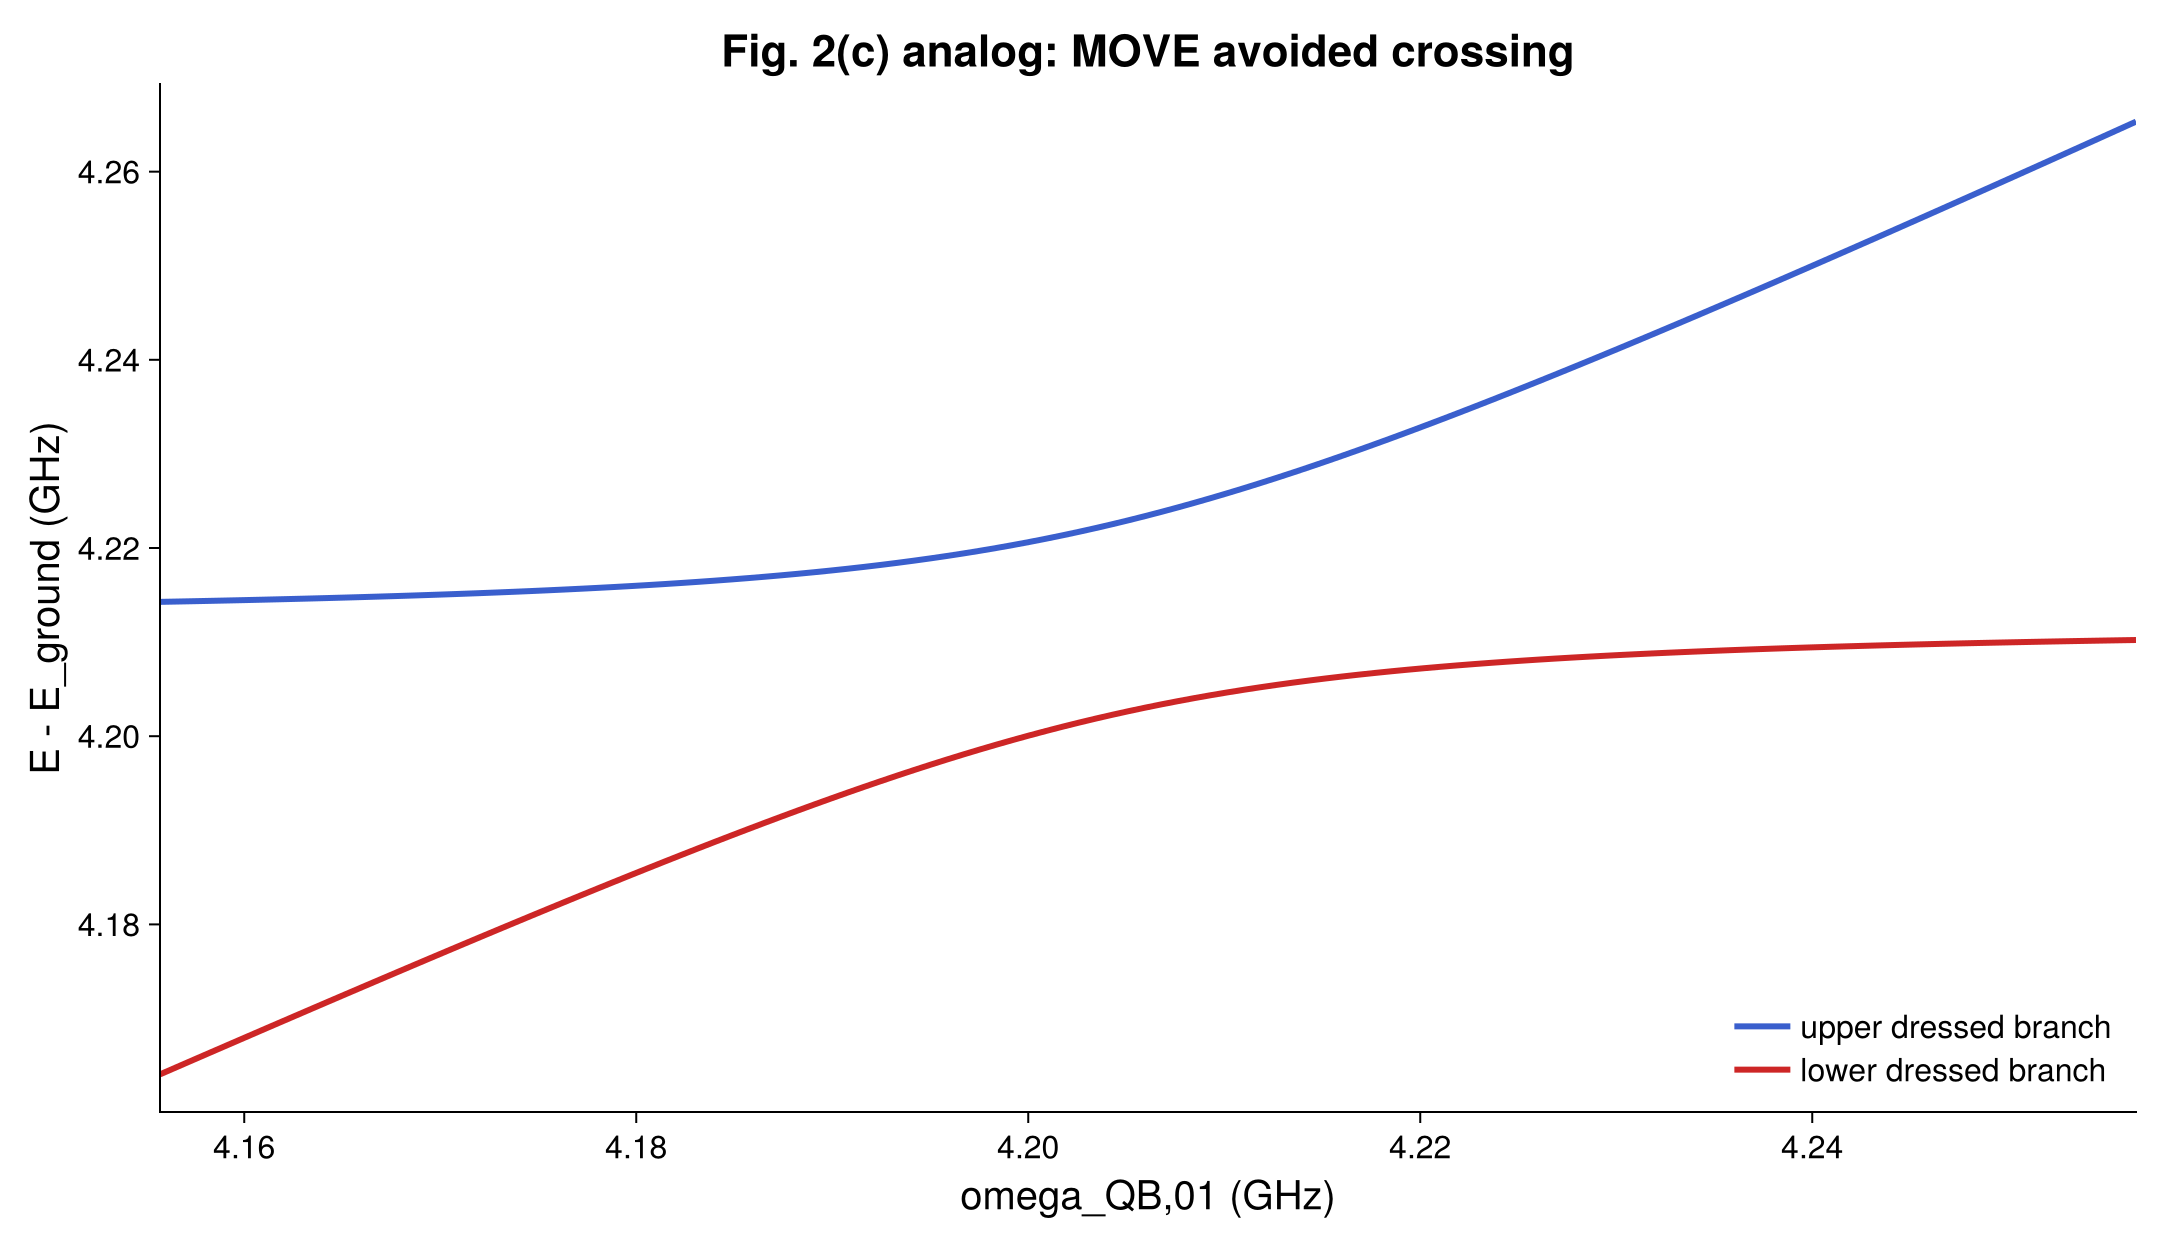

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2c_move_avoided_crossing.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2c_move_avoided_crossing.png"), plotted_tc_flux = 0.355, move_gap_034 = (tc_flux = 0.34, tc_ghz = 4.2231, q_flux = 0.2358, q_ghz = 4.1719, gap_ghz = 0.0548, overlap_floor = 0.4416), move_gap_0355 = (tc_flux = 0.355, tc_ghz = 3.9991, q_flux = 0.2314, q_ghz = 4.2039, gap_ghz = 0.0202, overlap_floor = 0.4847))

In [48]:
move_plot_tc_flux = FIG2_MOVE_PLOT_TC_FLUX
move_q_fluxes = collect(range(0.21, 0.25; length = 17))
move_rows = branch_tracking_rows(
    move_system,
    move_q_fluxes,
    move_plot_tc_flux;
    branch_pair_a = (1, 0, 0),
    branch_pair_b = (0, 0, 1),
    which = :move,
    branch = :move,
)

move_x = [row.q_ghz for row in move_rows]
move_upper = [row.upper_ghz for row in move_rows]
move_lower = [row.lower_ghz for row in move_rows]
move_fan_curves = nearby_fan_curves(move_rows; margin = 0.12)
move_background_y = fan_y_values(move_fan_curves)
move_y_values = vcat(move_upper, move_lower, move_background_y)
move_y_pad = 0.004
move_xlims = (minimum(move_x), maximum(move_x))
move_ylims = (minimum(move_y_values) - move_y_pad, maximum(move_y_values) + move_y_pad)

move_fig = line_figure(
    vcat(
        move_fan_curves,
        [
            (x = move_x, y = move_upper, label = "upper dressed branch", color = FIG2_COLORS.dressed_a),
            (x = move_x, y = move_lower, label = "lower dressed branch", color = FIG2_COLORS.dressed_b),
        ],
    );
    title = "Fig. 2(c) analog: MOVE avoided crossing",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "E - E_ground (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
    xlims = move_xlims,
    ylims = move_ylims,
)
move_saved = save_figure(move_fig, repo_root, "figure2c_move_avoided_crossing")
figure_exports[:figure2c] = move_saved

display(move_fig)

move_gap = tracked_gap_summary(
    move_system,
    collect(range(0.21, 0.25; length = 81)),
    move_plot_tc_flux;
    branch_pair_a = (1, 0, 0),
    branch_pair_b = (0, 0, 1),
    which = :move,
    branch = :move,
)

(
    saved = move_saved,
    plotted_tc_flux = round4(move_plot_tc_flux),
    move_gap = compact_namedtuple(move_gap),
)


## Step 4 - Fig. 2(d) analog: CZ resonance avoided crossing

The CZ-side avoided crossing is built on the `QB2-TC2-CR` branch. As in the paper, the horizontal axis is the qubit frequency during the gate, `omega_QB,01`, while the tracked dressed branches come from the `|eg1⟩` and `|fg0⟩` manifold.


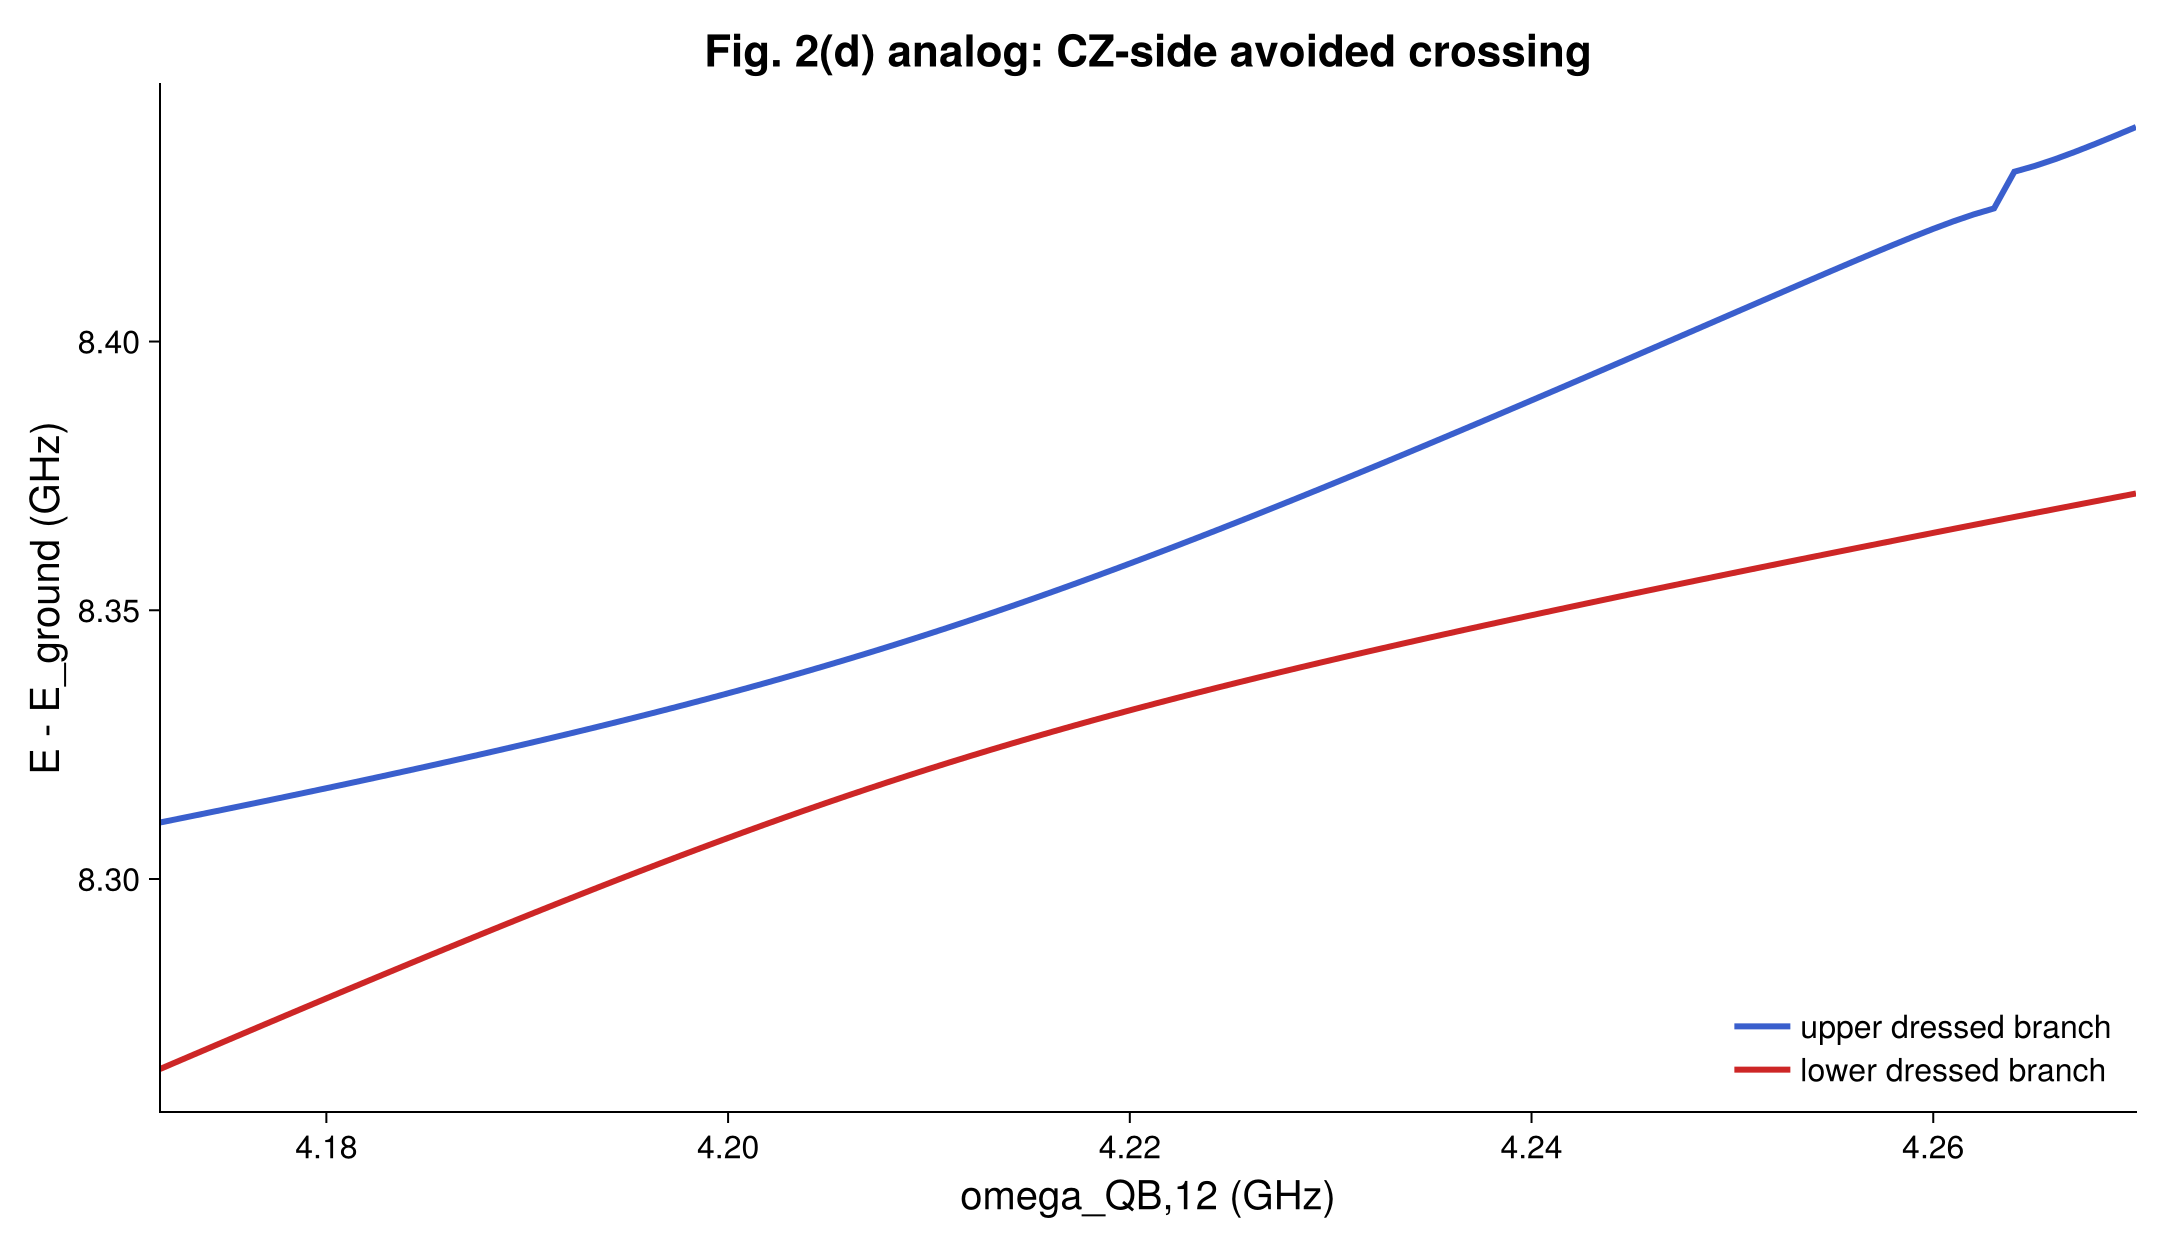

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2d_cz_avoided_crossing.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2d_cz_avoided_crossing.png"), plotted_tc_flux = 0.355, cz_gap_034 = (tc_flux = 0.34, tc_ghz = 4.2231, q_flux = 0.2428, q_ghz = 4.2238, gap_ghz = 0.0372, overlap_floor = 0.3653), cz_gap_0355 = (tc_flux = 0.355, tc_ghz = 3.9991, q_flux = 0.2442, q_ghz = 4.209, gap_ghz = 0.0251, overlap_floor = 0.459))

In [49]:
cz_plot_tc_flux = FIG2_CZ_PLOT_TC_FLUX
cz_q_fluxes = collect(range(0.16, 0.24; length = 17))
cz_rows = branch_tracking_rows(
    cz_system,
    cz_q_fluxes,
    cz_plot_tc_flux;
    branch_pair_a = (1, 0, 1),
    branch_pair_b = (2, 0, 0),
    which = :cz,
    branch = :cz,
)

cz_x = [row.q_ghz for row in cz_rows]
cz_upper = [row.upper_ghz for row in cz_rows]
cz_lower = [row.lower_ghz for row in cz_rows]
cz_fan_curves = nearby_fan_curves(cz_rows)
cz_background_y = fan_y_values(cz_fan_curves)
cz_y_values = vcat(cz_upper, cz_lower, cz_background_y)
cz_y_pad = 0.008
cz_xlims = (minimum(cz_x), maximum(cz_x))
cz_ylims = (minimum(cz_y_values) - cz_y_pad, maximum(cz_y_values) + cz_y_pad)

cz_fig = line_figure(
    vcat(
        cz_fan_curves,
        [
            (x = cz_x, y = cz_upper, label = "upper dressed branch", color = FIG2_COLORS.dressed_a),
            (x = cz_x, y = cz_lower, label = "lower dressed branch", color = FIG2_COLORS.dressed_b),
        ],
    );
    title = "Fig. 2(d) analog: CZ-side avoided crossing",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "E - E_ground (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
    xlims = cz_xlims,
    ylims = cz_ylims,
)
cz_saved = save_figure(cz_fig, repo_root, "figure2d_cz_avoided_crossing")
figure_exports[:figure2d] = cz_saved

display(cz_fig)

cz_gap = tracked_gap_summary(
    cz_system,
    collect(range(0.16, 0.24; length = 81)),
    cz_plot_tc_flux;
    branch_pair_a = (1, 0, 1),
    branch_pair_b = (2, 0, 0),
    which = :cz,
    branch = :cz,
)

(
    saved = cz_saved,
    plotted_tc_flux = round4(cz_plot_tc_flux),
    cz_gap = compact_namedtuple(cz_gap),
)


## Step 5 - Fig. 2(e) analog: fixed-window MOVE excited-state map

For the MOVE panel we initialize the local diabatic state `|eg0⟩` on the `QB1-TC1-CR` branch, hold the system at a static operating point for a fixed interaction window, and record the **final excited-state probability of the MOVE qubit**.

This is closer to the paper calibration workflow than the previous `|gg1⟩` target-state map and makes the panel interpretable as a local readout proxy rather than as a completed logical MOVE gate.


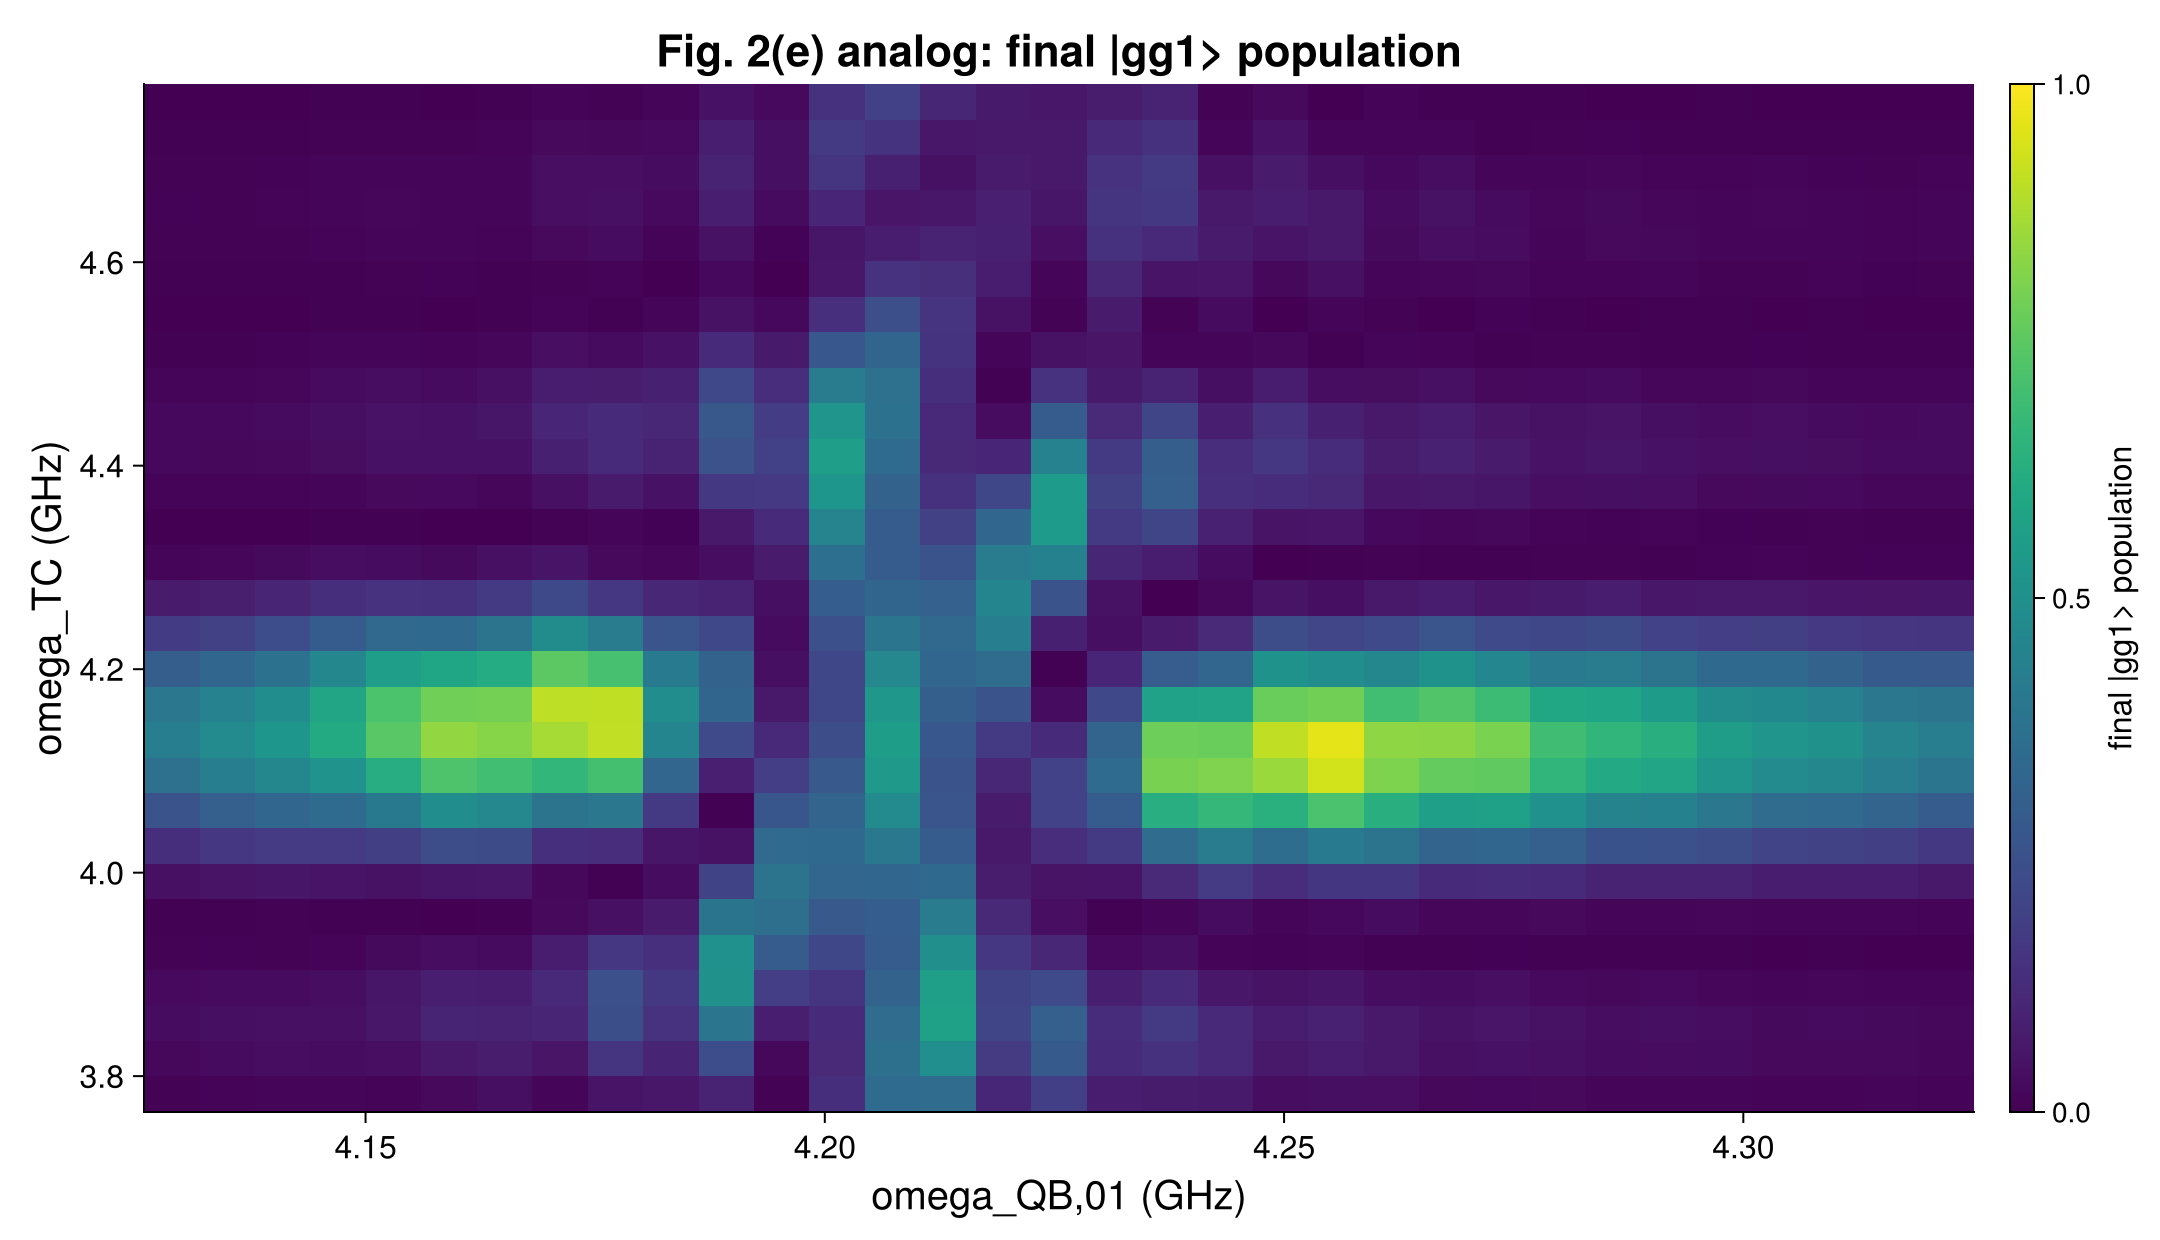

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2e_move_population_map.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2e_move_population_map.png"), move_t_gate = 150.0, best_move_point = (q_flux = 0.232, tc_flux = 0.3241, q_ghz = 4.1996, tc_ghz = 4.4507, value = 0.9615))

In [55]:
move_scan_q_fluxes = collect(range(0.20, 0.26; length = 25))
move_scan_tc_fluxes = collect(range(0.26, 0.38; length = 25))
move_t_gate = FIG2_MOVE_T_GATE

x_move, y_move, matrix_move = qubit_excited_scan(
    move_system,
    move_scan_q_fluxes,
    move_scan_tc_fluxes,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
)

x_move_sorted, y_move_sorted, matrix_move_sorted = ordered_heatmap_axes(x_move, y_move, matrix_move)
best_move_point = best_scan_point(move_scan_q_fluxes, move_scan_tc_fluxes, matrix_move; branch = :move, objective = :min)

move_heatmap_fig = heatmap_figure(
    x_move_sorted,
    y_move_sorted,
    matrix_move_sorted;
    title = "Fig. 2(e) analog: final MOVE-qubit excited-state probability",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
    colorlabel = "final P_e (MOVE qubit)",
    colorrange = (0.0, 1.0),
)
move_heatmap_saved = save_figure(move_heatmap_fig, repo_root, "figure2e_move_population_map")
figure_exports[:figure2e] = move_heatmap_saved

display(move_heatmap_fig)

(
    saved = move_heatmap_saved,
    move_t_gate = move_t_gate,
    best_move_point = compact_namedtuple(best_move_point),
)


## Step 6 - Fig. 2(f) analog: fixed-window CZ excited-state map

For the CZ panel we initialize `|eg1⟩` on the `QB2-TC2-CR` branch, hold at a static operating point, and record the **final excited-state probability of the CZ-branch qubit**.

Appendix D extracts the experimental CZ operating point through a higher-level sequence whose readout is routed through the MOVE qubit. This reduced notebook cannot represent that full sequence, so it uses the final excited-state probability of the isolated `QB2-TC2-CR` branch as the local proxy for the `|eg1⟩ ↔ |fg0⟩` exchange landscape.


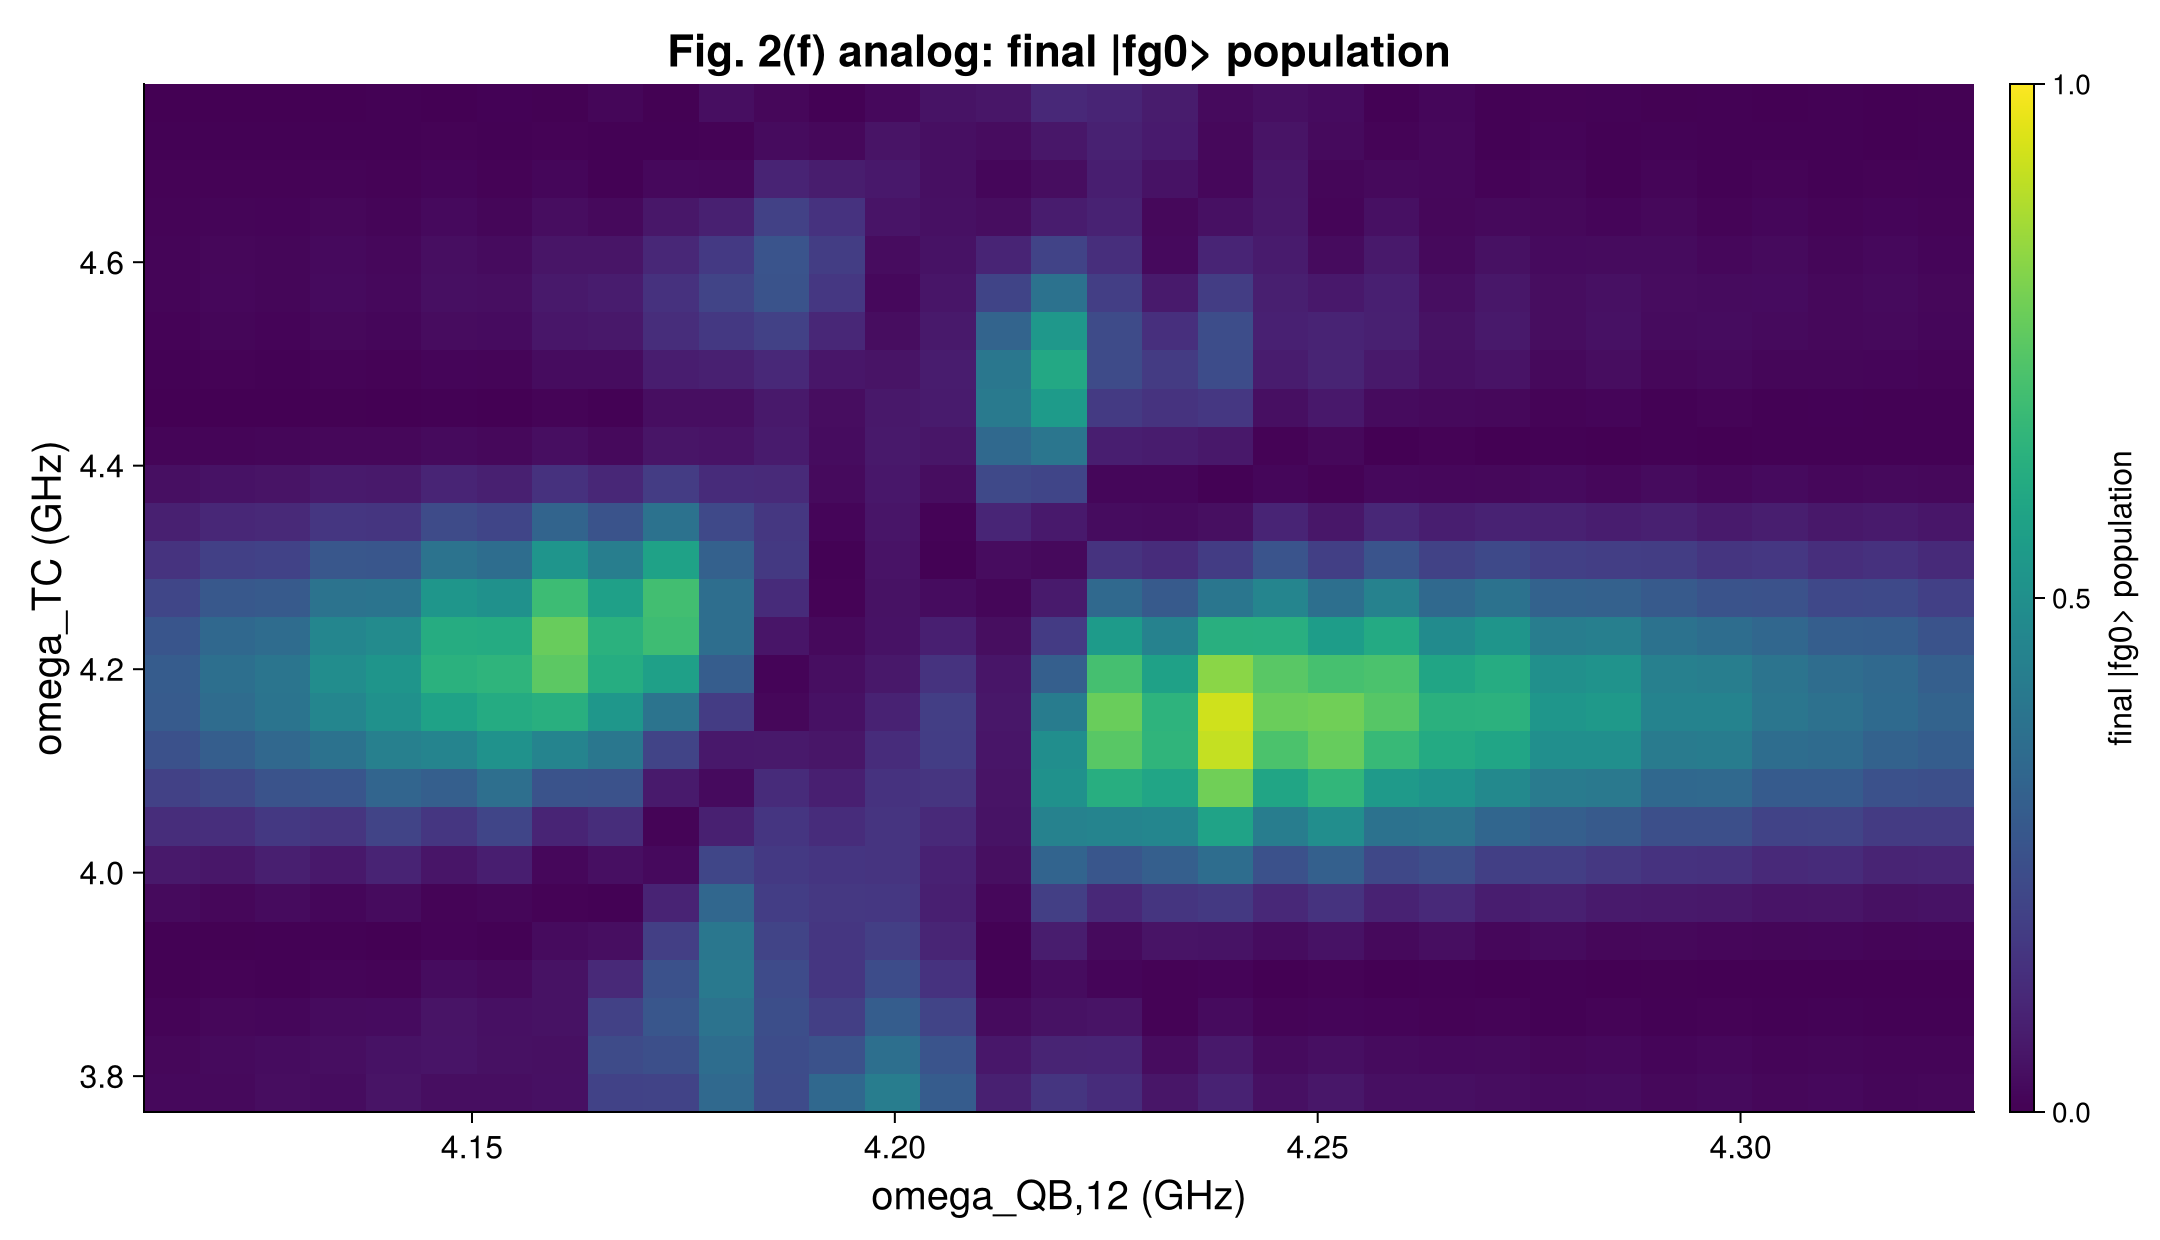

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2f_cz_population_map.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2f_cz_population_map.png"), cz_t_gate = 100.0, best_cz_point = (q_flux = 0.2455, tc_flux = 0.3284, q_ghz = 4.1962, tc_ghz = 4.3892, value = 0.9289))

In [56]:
cz_scan_q_fluxes = collect(range(0.16, 0.24; length = 25))
cz_scan_tc_fluxes = collect(range(0.26, 0.38; length = 25))
cz_t_gate = FIG2_CZ_T_GATE

x_cz, y_cz, matrix_cz = qubit_excited_scan(
    cz_system,
    cz_scan_q_fluxes,
    cz_scan_tc_fluxes,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
)

x_cz_sorted, y_cz_sorted, matrix_cz_sorted = ordered_heatmap_axes(x_cz, y_cz, matrix_cz)
best_cz_point = best_scan_point(cz_scan_q_fluxes, cz_scan_tc_fluxes, matrix_cz; branch = :cz, objective = :min)

cz_heatmap_fig = heatmap_figure(
    x_cz_sorted,
    y_cz_sorted,
    matrix_cz_sorted;
    title = "Fig. 2(f) analog: final CZ-qubit excited-state probability",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
    colorlabel = "final P_e (CZ qubit)",
    colorrange = (0.0, 1.0),
)
cz_heatmap_saved = save_figure(cz_heatmap_fig, repo_root, "figure2f_cz_population_map")
figure_exports[:figure2f] = cz_heatmap_saved

display(cz_heatmap_fig)

(
    saved = cz_heatmap_saved,
    cz_t_gate = cz_t_gate,
    best_cz_point = compact_namedtuple(best_cz_point),
)


## Step 7 - Quench sanity check and computational-phase interpretation

The previous two scan panels were computed by rebuilding the static Hamiltonian at each operating point. To confirm the same feature appears in a pulse-like picture, we now start from parked MOVE and CZ base systems and apply a constant `FluxControl` quench to the best scan points.

We also evaluate the computational `QB-CR` conditional phase at the best CZ-side scan point. In this reduced model, the phase stays near zero, which is the correct interpretation: panels (d) and (f) identify the **resonance mechanism**, not a finished calibrated computational CZ gate.


In [52]:
move_quench_population = quench_qubit_excited_population(
    move_system,
    best_move_point.q_flux,
    best_move_point.tc_flux,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
)

cz_quench_population = quench_qubit_excited_population(
    cz_system,
    best_cz_point.q_flux,
    best_cz_point.tc_flux,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
)

cz_phase_proxy = computational_phase_summary(cz_system, best_cz_point.q_flux, best_cz_point.tc_flux, cz_t_gate; branch = :cz)

(
    move_static_min = compact_namedtuple(best_move_point),
    move_quench_final_p_e = round4(move_quench_population),
    cz_static_min = compact_namedtuple(best_cz_point),
    cz_quench_final_p_e = round4(cz_quench_population),
    cz_computational_phase = compact_namedtuple(cz_phase_proxy),
)


(move_static_peak = (q_flux = 0.2315, tc_flux = 0.355, q_ghz = 4.2032, tc_ghz = 3.9991, value = 0.9589), move_quench_population = 0.9576, cz_static_peak = (q_flux = 0.2442, tc_flux = 0.355, q_ghz = 4.209, tc_ghz = 3.9991, value = 0.7943), cz_quench_population = 0.7921, cz_computational_phase = (q_flux = 0.2442, tc_flux = 0.355, q_ghz = 4.209, tc_ghz = 3.9991, conditional_phase_pi = 0.234, max_leakage = 0.0))

## Step 8 - Optional truncation cross-check

This notebook defaults to `charge_cutoff = 3` for interactivity. The cell below can rerun the best MOVE and CZ scan points at `charge_cutoff = 4` to check that the qualitative story survives a modest truncation increase.


In [53]:
if RUN_TRUNCATION_CHECKS
    move_cutoff4 = final_qubit_excited_population(
        move_system,
        best_move_point.q_flux,
        best_move_point.tc_flux,
        (1, 0, 0),
        move_t_gate;
        branch = :move,
        charge_cutoff = 4,
    )
    cz_cutoff4 = final_qubit_excited_population(
        cz_system,
        best_cz_point.q_flux,
        best_cz_point.tc_flux,
        (1, 0, 1),
        cz_t_gate;
        branch = :cz,
        charge_cutoff = 4,
    )

    (
        move_cutoff3 = round4(best_move_point.value),
        move_cutoff4 = round4(move_cutoff4),
        cz_cutoff3 = round4(best_cz_point.value),
        cz_cutoff4 = round4(cz_cutoff4),
    )
else
    "Set RUN_TRUNCATION_CHECKS = true to rerun the low-P_e scan points at charge_cutoff = 4."
end


"Set RUN_TRUNCATION_CHECKS = true to rerun the peak scan points at charge_cutoff = 4."

## Takeaways

- The notebook reproduces the **qualitative avoided-crossing physics** behind Fig. 2(c) and Fig. 2(d) with branch-specific exact-circuit local models.
- The MOVE and CZ map panels are now built from the paper-backed branch split `QB1-TC1-CR` and `QB2-TC2-CR`, respectively.
- The fixed-window scan maps are local **final qubit excited-state** readout proxies, not target-state transfer maps and not fully calibrated logical gates.
- The best CZ-side resonance point found here still does **not** by itself produce a large computational conditional phase, which is expected. A real logical gate still needs calibrated pulse timing, phase handling, and the higher-level `MOVE -> CZ -> MOVE` composition.


In [54]:
final_summary = (
    move_branch = branch_spec(:move).label,
    cz_branch = branch_spec(:cz).label,
    move_gap = compact_namedtuple(move_gap),
    cz_gap = compact_namedtuple(cz_gap),
    best_move_point = compact_namedtuple(best_move_point),
    best_cz_point = compact_namedtuple(best_cz_point),
    move_quench_final_p_e = round4(move_quench_population),
    cz_quench_final_p_e = round4(cz_quench_population),
    cz_computational_phase = compact_namedtuple(cz_phase_proxy),
    exported_figures = figure_exports,
)

final_summary


(move_gap_low = (tc_flux = 0.34, tc_ghz = 4.6326, q_flux = 0.2292, q_ghz = 4.2194, gap_ghz = 0.0034, overlap_floor = 0.5043), move_gap_high = (tc_flux = 0.355, tc_ghz = 4.3284, q_flux = 0.2292, q_ghz = 4.2194, gap_ghz = 0.0114, overlap_floor = 0.5206), cz_gap_low = (tc_flux = 0.34, tc_ghz = 4.6326, q_flux = 0.243, q_ghz = 4.2213, gap_ghz = 0.0049, overlap_floor = 0.7203), cz_gap_high = (tc_flux = 0.355, tc_ghz = 4.3284, q_flux = 0.2435, q_ghz = 4.2164, gap_ghz = 0.014, overlap_floor = 0.5026), best_move_point = (q_flux = 0.2315, tc_flux = 0.355, q_ghz = 4.2032, tc_ghz = 3.9991, value = 0.9589), best_cz_point = (q_flux = 0.2442, tc_flux = 0.355, q_ghz = 4.209, tc_ghz = 3.9991, value = 0.7943), move_quench_population = 0.9576, cz_quench_population = 0.7921, cz_computational_phase = (q_flux = 0.2442, tc_flux = 0.355, q_ghz = 4.209, tc_ghz = 3.9991, conditional_phase_pi = 0.234, max_leakage = 0.0), exported_figures = Dict{Symbol, NamedTuple}(:figure2d => (svg = "/Users/yalgaeahn/Research/2